# Exploratorio, preparacion y ML.

Problema: se desea conocer en que es mejor invertir, en el SPY o en un CDT a 4 años?

Pregunta smart: Que es mas rentable En un plazo de 4 años, invertir 20 millones de pesos colombianos en el SPY o en un CDT?, si tenemos en cuenta que la taza del CDT es de 9% efectivo anual.

Importancia de la columna:
Tomamos la informacion de un etf (SPY) de la siguiente URL: https://finance.yahoo.com/quote/SPY/history/?period1=728317800&period2=1723227557 La columna a analizar es el comportamiento historico del ETF SPY (close) que esta basado en el SYP500 el cual es un conjunto de acciones de las mejores 500 empresas de EEUU. necesitamos saber el comportamiento de cierre del ETF diario para poder deducir que es mejor a largo plazo invertir en este o colocar el dinero en un CDT a un plazo de 4 años.

# En este scrip principalmente vamos a contruir un modelo ideal para realizar la prediccion futura del SPY.

 Mostramos algunos graficos y almacenamos los datos, modelo, e informacion necesaria para ponerlo en producción.

In [1]:
!pip install torch
!pip install onnx
#!pip install dfply

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 41.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [2]:
import torch.nn as nn
import torch
import joblib
import torch.onnx
import numpy as np
import pandas as pd
#from dfply import *
#import pmdarima as pm
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
file_path = "https://raw.githubusercontent.com/jopachecoc/AD_1_preguntasmart/main/SPY.csv"
df = pd.read_csv(file_path)
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
7934,2024-08-05,511.640015,523.580017,510.269989,517.380005,517.380005,146267400
7935,2024-08-06,519.219971,529.750000,517.869995,522.150024,522.150024,84826300
7936,2024-08-07,528.469971,531.590027,518.049988,518.659973,518.659973,70698300
7937,2024-08-08,523.909973,531.289978,521.840027,530.650024,530.650024,62200000
7938,2024-08-09,529.809998,534.510010,528.559998,532.010010,532.010010,27476453


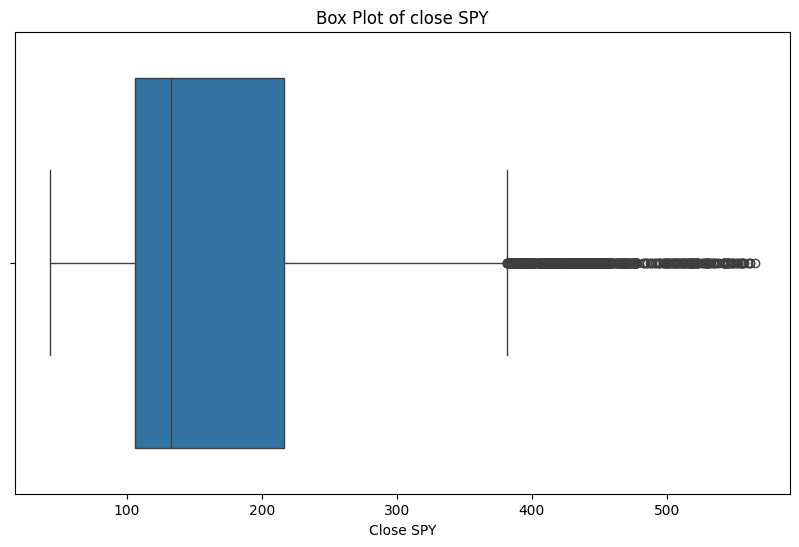

In [3]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Close'])
plt.title('Box Plot of close SPY')
plt.xlabel('Close SPY')
plt.show()

# esto me dice que tiene una tendencia exponencial ya que tiene atipicos hacia adelante osea de seguro crece
# mas rapido que un ajuste lineal, para esto podemos calcular el ln y aplicarlo en la variable y
# comparar resultados sobre su comportamiento.


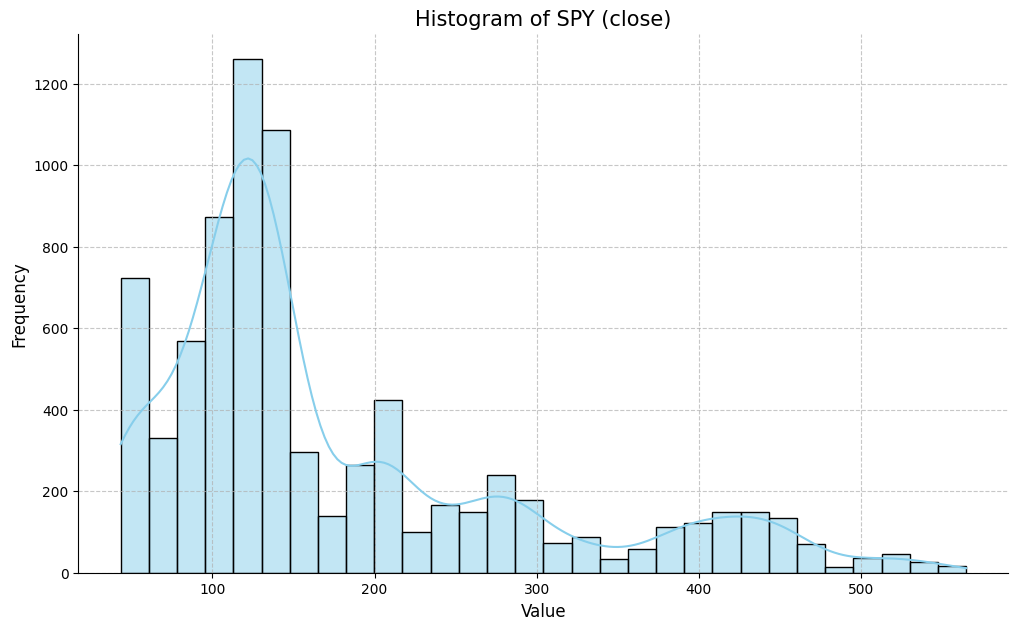

In [4]:
plt.figure(figsize=(12, 7))
sns.histplot(df['Close'], bins=30, kde=True, color='skyblue', edgecolor='black')

# Adding titles and labels
plt.title('Histogram of SPY (close)', fontsize=15)
plt.xlabel('Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Customizing the style
plt.grid(True, linestyle='--', alpha=0.7)
sns.despine()

# Display the plot
plt.show()

#ser muy habil para poder tomar los valores altos de la serie

In [5]:
# Seleccionamos solo la columna de interés
serie = df["Close"].values.reshape(-1, 1)

In [6]:
# Escalar la serie
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
serie_escalada = scaler.fit_transform(serie)

In [7]:
def crear_ventanas(datos, ventana=30):
    X, y = [], []
    for i in range(len(datos) - ventana):
        X.append(datos[i:i+ventana])
        y.append(datos[i+ventana])
    return np.array(X), np.array(y)

X, y = crear_ventanas(serie_escalada, ventana=30)

In [8]:
X_tensor = torch.tensor(X, dtype=torch.float32)  # (N, ventana, 1)
y_tensor = torch.tensor(y, dtype=torch.float32)

In [10]:
# Modelo LSTM
class LSTMRegresor(nn.Module):
    def __init__(self, input_size=1, hidden_size=104, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

modelo = LSTMRegresor()
criterio = nn.MSELoss()
optimizador = torch.optim.Adam(modelo.parameters(), lr=0.005)


# Dividir datos en entrenamiento y prueba
porcentaje_train = 0.8
tamaño_train = int(len(X_tensor) * porcentaje_train)
X_train, y_train = X_tensor[:tamaño_train], y_tensor[:tamaño_train]
X_test, y_test = X_tensor[tamaño_train:], y_tensor[tamaño_train:]


In [11]:
#guardamos la informacion de pruebas.
np.save('X_test.npy', X_test.numpy())
np.save('y_test.npy', y_test.numpy())


In [12]:
# Entrenamiento
for epoca in range(50):
    modelo.train()
    salida = modelo(X_train)
    perdida = criterio(salida, y_train)
    optimizador.zero_grad()
    perdida.backward()
    optimizador.step()
    if (epoca + 1) % 10 == 0:
        print(f"Época {epoca+1}, Pérdida: {perdida.item():.4f}")


Época 10, Pérdida: 0.0113
Época 20, Pérdida: 0.0068
Época 30, Pérdida: 0.0044
Época 40, Pérdida: 0.0010
Época 50, Pérdida: 0.0004


In [13]:
# Predicción
modelo.eval()

predicciones_train = modelo(X_train).detach().numpy()
predicciones_train_inv = scaler.inverse_transform(predicciones_train)
y_train_invertido = scaler.inverse_transform(y_train.numpy())
predicciones_train_inv_tensor = torch.tensor(predicciones_train_inv, dtype=torch.float32).view(-1, 1)
y_train_invertido_tensor = torch.tensor(y_train_invertido, dtype=torch.float32).view(-1, 1)


predicciones_t = modelo(X_test).detach().numpy()
predicciones_invertidas_t = scaler.inverse_transform(predicciones_t)
y_test_invertido = scaler.inverse_transform(y_test.numpy())
predicciones_test_inv_tensor = torch.tensor(predicciones_invertidas_t, dtype=torch.float32).view(-1, 1)
y_test_invertido_tensor = torch.tensor(y_test_invertido, dtype=torch.float32).view(-1, 1)



In [15]:
mse = nn.MSELoss()

# Calcular pérdida MSE
mse_entrenamiento = mse(predicciones_train_inv_tensor, y_train_invertido_tensor).item()
print("MSE entrenamiento:", mse_entrenamiento)
# Calcular pérdida MSE
mse_prueba = mse(predicciones_test_inv_tensor, y_test_invertido_tensor).item()
print("MSE prueba:", mse_prueba)



MSE entrenamiento: 137.7185516357422
MSE prueba: 45.510154724121094


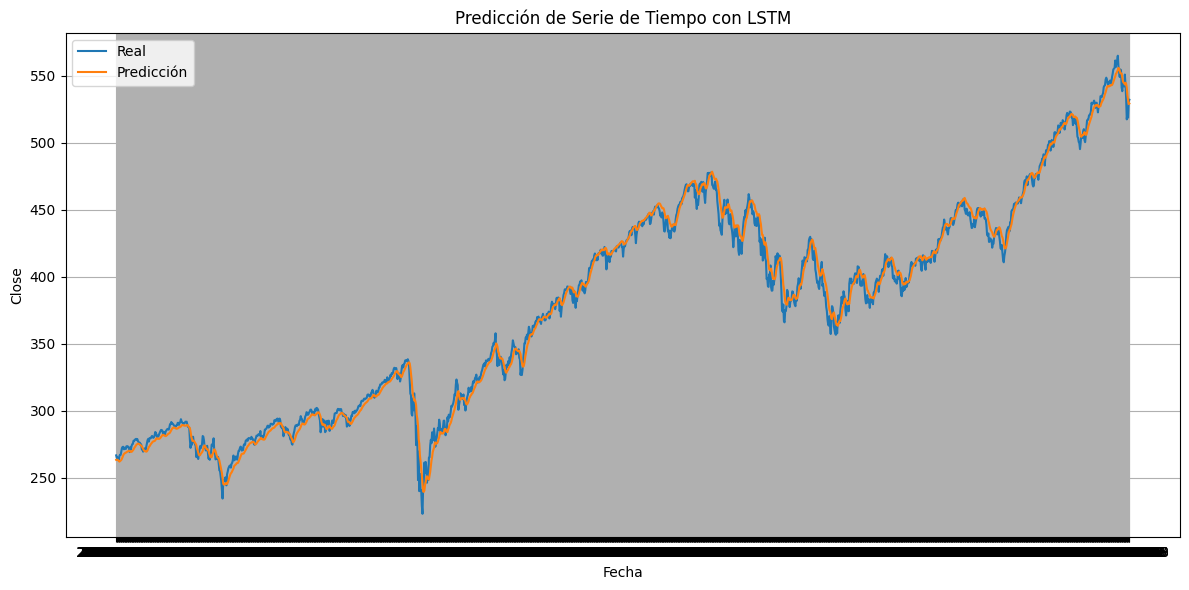

In [16]:
# Graficar
fechas = df["Date"].values[-len(y_test):]
plt.figure(figsize=(12,6))
plt.plot(fechas, y_test_invertido, label="Real")
plt.plot(fechas, predicciones_test_inv_tensor, label="Predicción")
plt.title("Predicción de Serie de Tiempo con LSTM")
plt.xlabel("Fecha")
plt.ylabel("Close")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

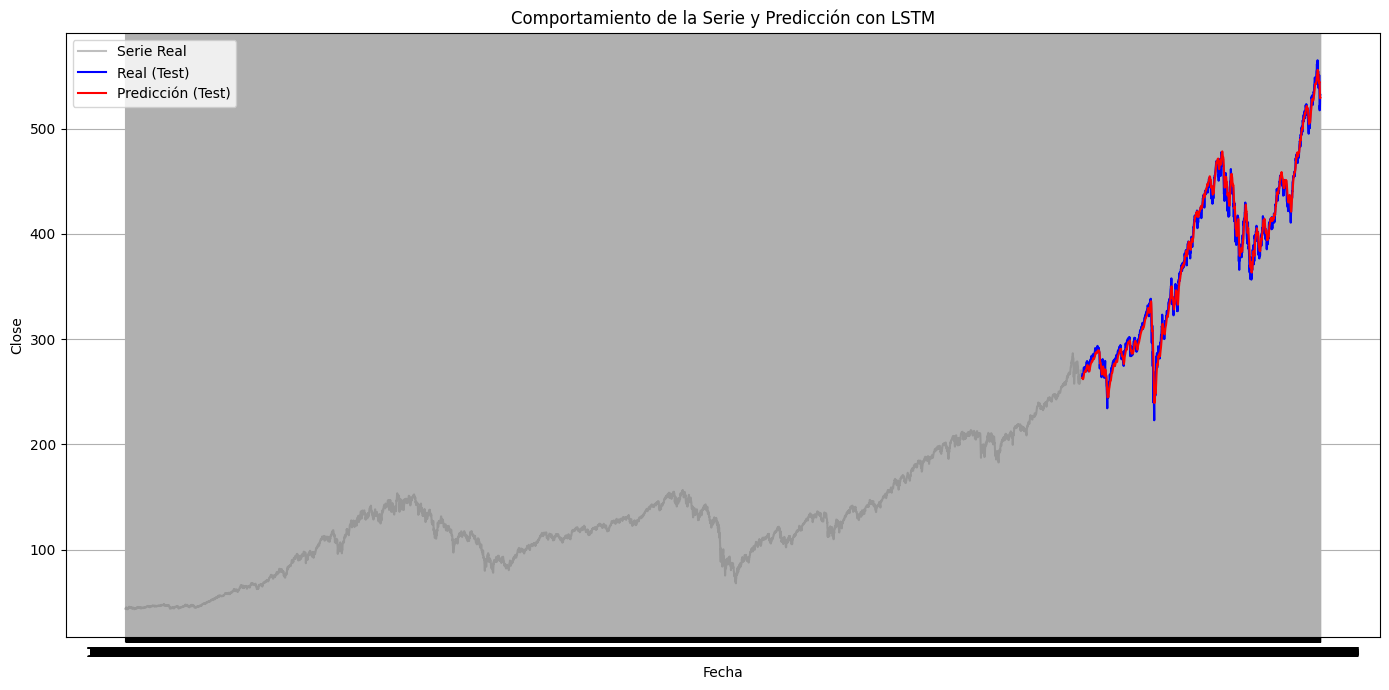

In [17]:
plt.figure(figsize=(14, 7))
# Serie completa real
plt.plot(df["Date"], df["Close"], label="Serie Real", color="gray", alpha=0.5)
# Real en test
plt.plot(fechas, y_test_invertido, label="Real (Test)", color="blue")
# Predicción en test
plt.plot(fechas, predicciones_test_inv_tensor, label="Predicción (Test)", color="red")
plt.title("Comportamiento de la Serie y Predicción con LSTM")
plt.xlabel("Fecha")
plt.ylabel("Close")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [18]:
def predecir_futuro(modelo, ultima_ventana, pasos=10):
    modelo.eval()
    predicciones = []

    entrada = ultima_ventana.clone().detach()  # (1, ventana, 1)

    with torch.no_grad():
        for _ in range(pasos):
            salida = modelo(entrada)
            predicciones.append(salida.item())

            # Actualizar la ventana: quitar el primero, añadir la nueva predicción
            nueva_entrada = salida.view(1, 1, 1)
            entrada = torch.cat([entrada[:, 1:, :], nueva_entrada], dim=1)

    return predicciones

In [19]:
# Tomamos la última ventana del conjunto de prueba
ultima_ventana = X_test[-1].unsqueeze(0)  # (1, ventana, 1)

# Predecimos 10 pasos futuros
pred_futuro = predecir_futuro(modelo, ultima_ventana, pasos=10)

# Inversión del escalado si estás usando MinMaxScaler
pred_futuro_invertido = scaler.inverse_transform(np.array(pred_futuro).reshape(-1, 1)).flatten()


In [20]:
ultima_fecha = pd.to_datetime(df["Date"].iloc[-1])
fechas_futuras = pd.date_range(start=ultima_fecha + pd.Timedelta(days=1), periods=10)


In [21]:
pred_futuro_invertido

array([529.16617956, 529.23704438, 529.29165381, 529.29553895,
       529.26709977, 529.22374169, 529.17506874, 529.1255566 ,
       529.0764796 , 529.02814855])

In [22]:
plt.figure(figsize=(14, 7))
# Serie real completa
plt.plot(df["Date"], df["Close"], label="Serie Real", color="gray", alpha=0.5)
# Valores reales de test
plt.plot(fechas, y_test_invertido, label="Real (Test)", color="blue")
# Predicciones sobre test
plt.plot(fechas, predicciones_invertidas, label="Predicción (Test)", color="red")
# Predicciones futuras
plt.plot(fechas_futuras, pred_futuro_invertido, label="Predicción Futura", color="green", linestyle="--", marker="o")
plt.title("Predicción con LSTM - Serie Real, Test y Futuro")
plt.xlabel("Fecha")
plt.ylabel("Close")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


NameError: name 'predicciones_invertidas' is not defined

Error in callback <function _draw_all_if_interactive at 0x794dc444efc0> (for post_execute):


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x794dc444cae0> (for post_execute):


KeyboardInterrupt: 

## Vamos a importar la fucnoin de scalado


In [23]:
joblib.dump(scaler, "scalerLSTM.pkl")  # Guarda el objeto scaler en un archivo

['scalerLSTM.pkl']

## crear y exportar el modelo a onnx


In [25]:
# Cambiar a modo evaluación
modelo.eval()

LSTMRegresor(
  (lstm): LSTM(1, 104, batch_first=True)
  (fc): Linear(in_features=104, out_features=1, bias=True)
)

In [26]:
# Crear entrada dummy (por ejemplo, batch=1, secuencia=30, features=1)
entrada_dummy = ultima_ventana.clone().detach()

In [27]:
# Exportar a ONNX
torch.onnx.export(
    modelo,
    entrada_dummy,
    "modelo_lstm.onnx",
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={"input": {0: "batch_size", 1: "sequence_length"}, "output": {0: "batch_size"}},
    opset_version=11
)

/usr/local/lib/python3.11/dist-packages/torch/onnx/symbolic_opset9.py:4277: UserWarning: Exporting a model to ONNX with a batch_size other than 1, with a variable length with LSTM can cause an error when running the ONNX model with a different batch size. Make sure to save the model with a batch size of 1, or define the initial states (h0/c0) as inputs of the model. 
  warnings.warn(
